In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load S&P 500 data
import yfinance as yf

import pandas as pd


sp500 = yf.Ticker("^GSPC")
data = sp500.history(period="max")


In [ ]:
# Display the first 5 rows of the raw data
print("Raw S&P 500 Data:")
print(data.head())


Raw S&P 500 Data:
                                Open       High        Low      Close  Volume  \
Date                                                                            
1927-12-30 00:00:00-05:00  17.660000  17.660000  17.660000  17.660000       0   
1928-01-03 00:00:00-05:00  17.760000  17.760000  17.760000  17.760000       0   
1928-01-04 00:00:00-05:00  17.719999  17.719999  17.719999  17.719999       0   
1928-01-05 00:00:00-05:00  17.549999  17.549999  17.549999  17.549999       0   
1928-01-06 00:00:00-05:00  17.660000  17.660000  17.660000  17.660000       0   

                           Dividends  Stock Splits  
Date                                                
1927-12-30 00:00:00-05:00        0.0           0.0  
1928-01-03 00:00:00-05:00        0.0           0.0  
1928-01-04 00:00:00-05:00        0.0           0.0  
1928-01-05 00:00:00-05:00        0.0           0.0  
1928-01-06 00:00:00-05:00        0.0           0.0  


In [ ]:

# Preprocessing: Use only the 'Close' prices
data = data[['Close']]
data = data.dropna()

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [ ]:
# Create a DataFrame from the scaled data
scaled_df = pd.DataFrame(scaled_data, columns=['Normalized Close'])

# Display the first 5 rows of normalized data
print("\nNormalized Data:")
print(scaled_df.head())



Normalized Data:
   Normalized Close
0          0.002204
1          0.002220
2          0.002214
3          0.002185
4          0.002204


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - loss: 2.4833e-04 - val_loss: 0.0011
Epoch 2/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 79s 65ms/step - loss: 3.6603e-05 - val_loss: 4.4422e-04
Epoch 3/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - loss: 3.7085e-05 - val_loss: 8.3484e-04
Epoch 4/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 38s 62ms/step - loss: 3.5875e-05 - val_loss: 3.7923e-04
Epoch 5/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - loss: 3.5149e-05 - val_loss: 7.3501e-04
Epoch 6/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - loss: 3.1109e-05 - val_loss: 1.8559e-04
Epoch 7/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - loss: 3.9106e-05 - val_loss: 1.6330e-04
Epoch 8/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - loss: 3.4205e-05 - val_loss: 0.0016
Epoch 9/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - loss: 3.3267e-05 - val_loss: 0.0049
Epoch 10/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 38s 62ms/step - loss: 3.4153e-05 - val_loss: 8.6867e-04
Epoch 11/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - loss:

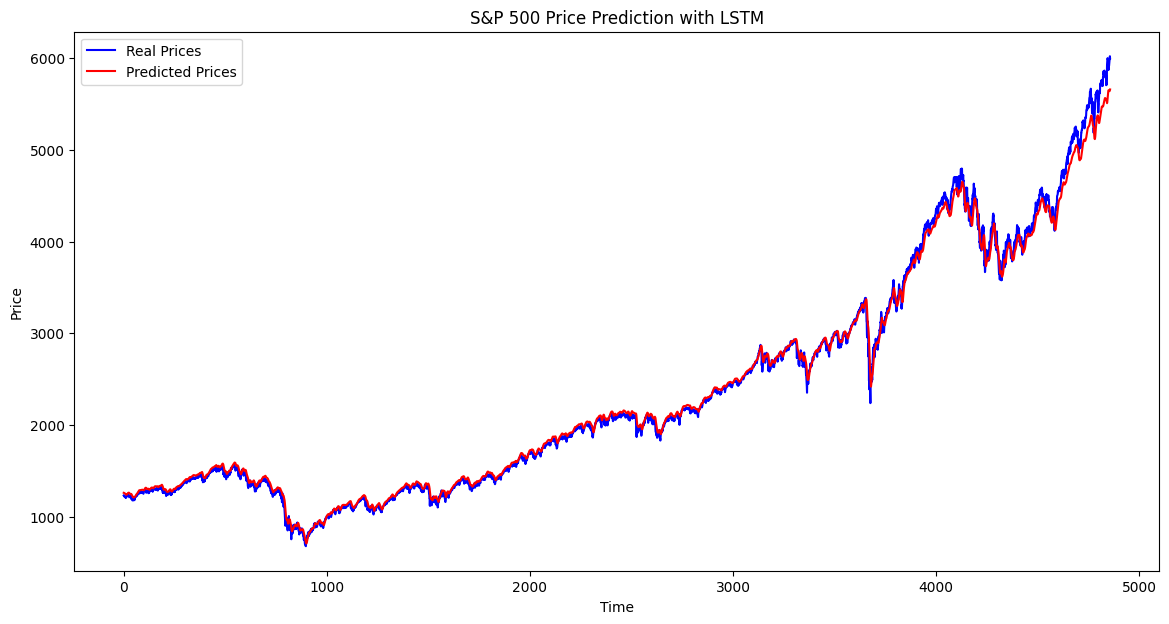

In [ ]:

# Create sequences for LSTM
def create_sequences(data, sequence_length=60):
    sequences = []
    labels = []
    for i in range(sequence_length, len(data)):
        sequences.append(data[i-sequence_length:i])
        labels.append(data[i, 0])
    return np.array(sequences), np.array(labels)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, callbacks=[early_stop])

# Predict on the test set
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot predictions vs actual prices
plt.figure(figsize=(14, 7))
plt.plot(real_prices, label="Real Prices", color='blue')
plt.plot(predicted_prices, label="Predicted Prices", color='red')
plt.title("S&P 500 Price Prediction with LSTM")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()




In [ ]:
# Create a DataFrame to compare predicted and actual prices
comparison_df = pd.DataFrame({
    'Real Price': real_prices.flatten(),
    'Predicted Price': predicted_prices.flatten()
})

# Display the first 10 rows of comparison data
print("\nComparison of Real vs Predicted Prices:")
print(comparison_df.head(10))



Comparison of Real vs Predicted Prices:
    Real Price  Predicted Price
0  1230.390015      1259.283325
1  1233.869995      1258.834839
2  1219.339966      1258.753784
3  1220.239990      1257.302734
4  1219.020020      1255.336304
5  1219.709961      1253.154785
6  1221.729980      1251.155273
7  1217.589966      1249.686157
8  1209.589966      1248.215454
9  1212.369995      1246.026123
